NumPy Correlation: 0.3799071103565295


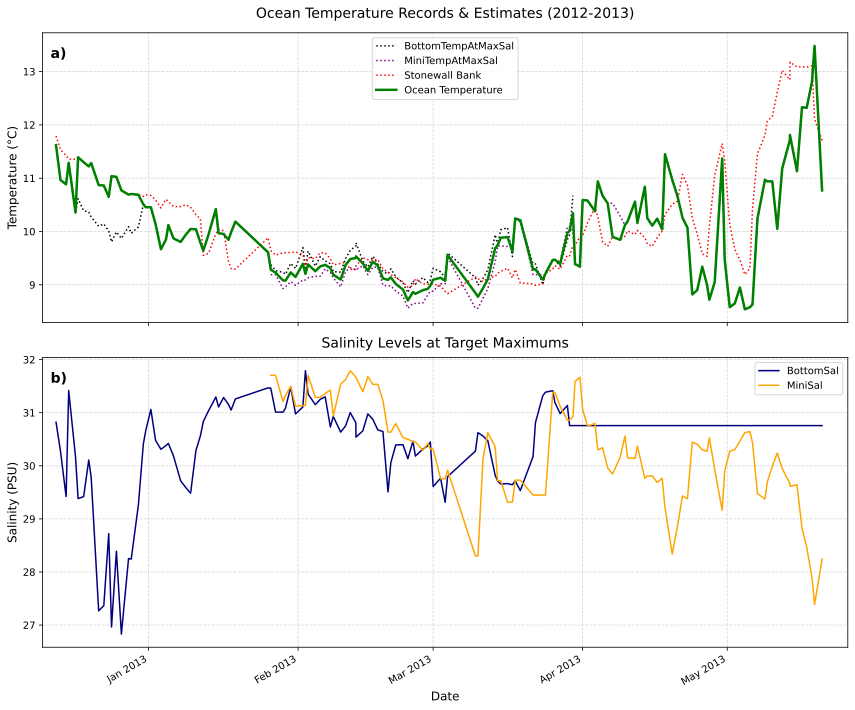

In [1]:
import pandas as pd
import scipy.io as sio
from scipy import signal
from scipy import stats
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import re
%config InlineBackend.figure_format = 'svg'

# 1. --- Load Datasets ---
downRiverDF = pd.read_csv('downriver_2012_2013_processed.csv', parse_dates = ['DN'])
minilanderDF = pd.read_csv('minilander_2012_2013_processed.csv', parse_dates = ['DN'])

# Metrics & Correlations
correlation = signal.correlate(downRiverDF["BottomPressure"].ffill().bfill().to_numpy(), downRiverDF["BottomSalCorrected"].ffill().bfill().to_numpy(), mode="full")
lags = signal.correlation_lags(downRiverDF["BottomPressure"].ffill().bfill().to_numpy().size, downRiverDF["BottomSalCorrected"].ffill().bfill().to_numpy().size, mode="full") 
lag = lags[np.argmax(correlation)]
numpy_correlation = np.corrcoef(downRiverDF["BottomPressure"].ffill().bfill().to_numpy(), downRiverDF["BottomSalCorrected"].ffill().bfill().to_numpy())[0, 1]
print('NumPy Correlation:', numpy_correlation)
res = stats.pearsonr(downRiverDF["BottomPressure"].ffill().bfill().to_numpy(), downRiverDF["BottomSalCorrected"].ffill().bfill().to_numpy())

# Create day DN to separate out data values by day instead of 5 min intervals
downRiverDF['dayDN'] = downRiverDF['DN'].dt.floor('D')
minilanderDF['dayDN'] = minilanderDF['DN'].dt.floor('D')

# Takes highest sal values by day and collects idx, then converts floats to integers
idxMaxDownArray = downRiverDF.groupby("dayDN")["BottomSalCorrected"].idxmax().ffill().astype('Int64').to_numpy()
idxMaxMiniArray = minilanderDF.groupby("dayDN")["Salinity"].idxmax().ffill().bfill().astype('Int64').to_numpy()

# Filter data frame from NAN duplicates created in previous step
salToTempDownDF = downRiverDF.loc[idxMaxDownArray].drop_duplicates()
salToTempMiniDF = minilanderDF.loc[idxMaxMiniArray].drop_duplicates()

# Combine so that both arrays are same length
combinedDF = pd.merge_asof(salToTempDownDF, salToTempMiniDF, on = 'DN')[["DN", "BottomTemp", "Temperature", "BottomSalCorrected", "Salinity"]]
maxDN = combinedDF["DN"].max()

# Adding empty columns to allow for concat to work
salToTempMiniDF["BottomTemp"] = np.nan
salToTempMiniDF["BottomSalCorrected"] = np.nan

# Combining tail of minilander data to other data
combinedDF = pd.concat([combinedDF, salToTempMiniDF.loc[salToTempMiniDF['DN']>maxDN][["DN", "BottomTemp", "Temperature", "BottomSalCorrected", "Salinity"]]])

# STONEWALL BANK OCEAN TEMPERATURE
stonewallDF = pd.concat([pd.read_csv('2012_stonewall.csv'), pd.read_csv('2013_stonewall.csv')])
# format time series
stonewallDF["dayDN"] = (pd.to_datetime(stonewallDF['YY'].astype(str) + '/' + stonewallDF['MM'].astype(str) + '/' + stonewallDF['DD'].astype(str) + '/' , format='mixed'))
# isolate and group by average value for that day
dailyStonewallDF = stonewallDF.groupby("dayDN").agg(dailyAverage = ("WTMP", "mean")).reset_index()
# get the time series to be the same size
combinedDF = pd.merge_asof(combinedDF, dailyStonewallDF, left_on = "DN", right_on = "dayDN")


# 2. --- DROP THE SPECIFIC 4 DAILY VALUE ROWS & INTERPOLATE ---
dip_dates = ['2013-01-19', '2013-03-04', '2013-03-21', '2013-03-30']

# Convert target dates to datetime format to match the DN column
target_datetimes = pd.to_datetime(dip_dates).date

# Set the BottomSalCorrected column to NaN for just those 4 single daily rows
combinedDF.loc[combinedDF['DN'].dt.date.isin(target_datetimes), 'BottomSalCorrected'] = np.nan

# Cleanly interpolate between the previous and next daily data points
combinedDF['BottomSalCorrected'] = combinedDF['BottomSalCorrected'].interpolate(method='linear')


# --- LOAD ALSEA FLOW DATAFRAME ---
flowDF = pd.read_csv('2012_2013alsea.csv')
flowDF['fRate'] = flowDF['max_va'] * 0.0283168

# Convert flow timeline
flowDF['DN'] = pd.to_datetime(dict(year=flowDF['begin_yr'].astype(int), 
                                   month=flowDF['month_nu'].astype(int), 
                                   day=flowDF['day_nu'].astype(int)))

# Force unique dates in flowDF by taking the daily mean if duplicate records exist
flowDF_daily = flowDF.groupby(flowDF['DN'].dt.date).agg({'fRate': 'mean'}).reset_index()
flowDF_daily.rename(columns={'DN': 'date_only'}, inplace=True)
flowDF_daily.to_csv('adjustedflow1213.csv', index=False)

# Align timelines explicitly by standard date formats
combinedDF['date_only'] = combinedDF['DN'].dt.date
combinedDF = pd.merge(combinedDF, flowDF_daily, on='date_only', how='left')


# 3. --- Run Averages & Calculations with Flow Rule Threshold ---
for index, row in combinedDF.iterrows():
    if not np.isnan(row["fRate"]) and row["fRate"] > 100:
        combinedDF.loc[index, "AvgEstimatedTemp"] = row["dailyAverage"]
    else:
        dataPoint = 0
        countER = 0
        if not np.isnan(row["BottomTemp"]):
            dataPoint += row["BottomTemp"]
            countER += 1
        if not np.isnan(row["Temperature"]):
            dataPoint += row["Temperature"]
            countER += 1    
        if countER > 0:
            combinedDF.loc[index, "AvgEstimatedTemp"] = dataPoint / countER

for index, row in combinedDF.iterrows():
    dataPoints = 0
    counTER = 0
    if not np.isnan(row["BottomSalCorrected"]):
        dataPoints += row["BottomSalCorrected"]
        counTER += 1
    if not np.isnan(row["Salinity"]):
        dataPoints += row["Salinity"]
        counTER += 1 
    if counTER > 0:
        dataPoints = dataPoints/counTER
        combinedDF.loc[index, "oceanSalEstimate"] = dataPoints

combinedDF = combinedDF.drop(columns=['date_only'])
combinedDF.to_csv('ocean_temperature12_13.csv', index=False)

# ==========================================
# 4. --- CREATE MATPLOTLIB SUBPLOT FIGURE ---
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- TOP SUBPLOT: TEMPERATURE RECORDS ---
ax1.plot(combinedDF['DN'], combinedDF["BottomTemp"], color='black', linestyle=':', label='BottomTempAtMaxSal')
ax1.plot(combinedDF['DN'], combinedDF["Temperature"], color='purple', linestyle=':', label='MiniTempAtMaxSal')
ax1.plot(combinedDF['DN'], combinedDF["dailyAverage"], color='red', linestyle=':', label='Stonewall Bank')
ax1.plot(combinedDF['DN'], combinedDF["AvgEstimatedTemp"], color='green', linewidth=2.5, label='Ocean Temperature')

ax1.set_ylabel('Temperature (°C)', fontsize=12)
ax1.set_title('Ocean Temperature Records & Estimates (2012-2013)', fontsize=14, pad=15)
ax1.legend(loc='upper center', frameon=True)
ax1.grid(True, linestyle='--', alpha=0.5)

# ADDED: Top-left text marker 'a)'
ax1.text(0.01, 0.95, 'a)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')


# --- BOTTOM SUBPLOT: SALINITY RECORDS ---
ax2.plot(combinedDF['DN'], combinedDF["BottomSalCorrected"], color='navy', label='BottomSal')
ax2.plot(combinedDF['DN'], combinedDF["Salinity"], color='orange', label='MiniSal')

ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Salinity (PSU)', fontsize=12)
ax2.set_title('Salinity Levels at Target Maximums', fontsize=14, pad=10)
ax2.legend(loc='upper right', frameon=True)
ax2.grid(True, linestyle='--', alpha=0.5)

# ADDED: Top-left text marker 'b)'
ax2.text(0.01, 0.95, 'b)', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')


# --- AXES & TIMELINE CONFIGURATIONS ---
start_date = pd.Timestamp('2012-12-10')
end_date = pd.Timestamp('2013-05-26')
ax2.set_xlim(start_date, end_date)

ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=30)

plt.tight_layout()
plt.show()